In [ ]:
from pathlib import Path
import sys

import torch
import numpy as np
import networkx as nx
import igraph as ig
import matplotlib.pyplot as plt
import seaborn as sns
from torch_geometric.datasets import TUDataset

# Ensure project root is in path
PROJECT_ROOT = Path(__file__).resolve().parent.parent if "__file__" in globals() else Path(".").resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data_utils import pytorch_to_networkx, networkx_to_igraph, DatasetPT
from src.graph_analysis import analyze_single_graph, calculate_annd_error
from src.generate_datasets import generate_graph
from notebooks.visualization_utils import plot_graph, plot_annd

In [ ]:
DATASET = "Mutagenicity"
METHOD = "anndg"  # Options: "padma", "anndg", etc.
IDX = 316

try:
    dataset = DatasetPT(PROJECT_ROOT / "data" / DATASET / f"{DATASET}_original.pt")
except:
    dataset = TUDataset(PROJECT_ROOT / "data", name=DATASET)

GRAPH_NX = pytorch_to_networkx(dataset[IDX])
GRAPH_IG = networkx_to_igraph(GRAPH_NX)

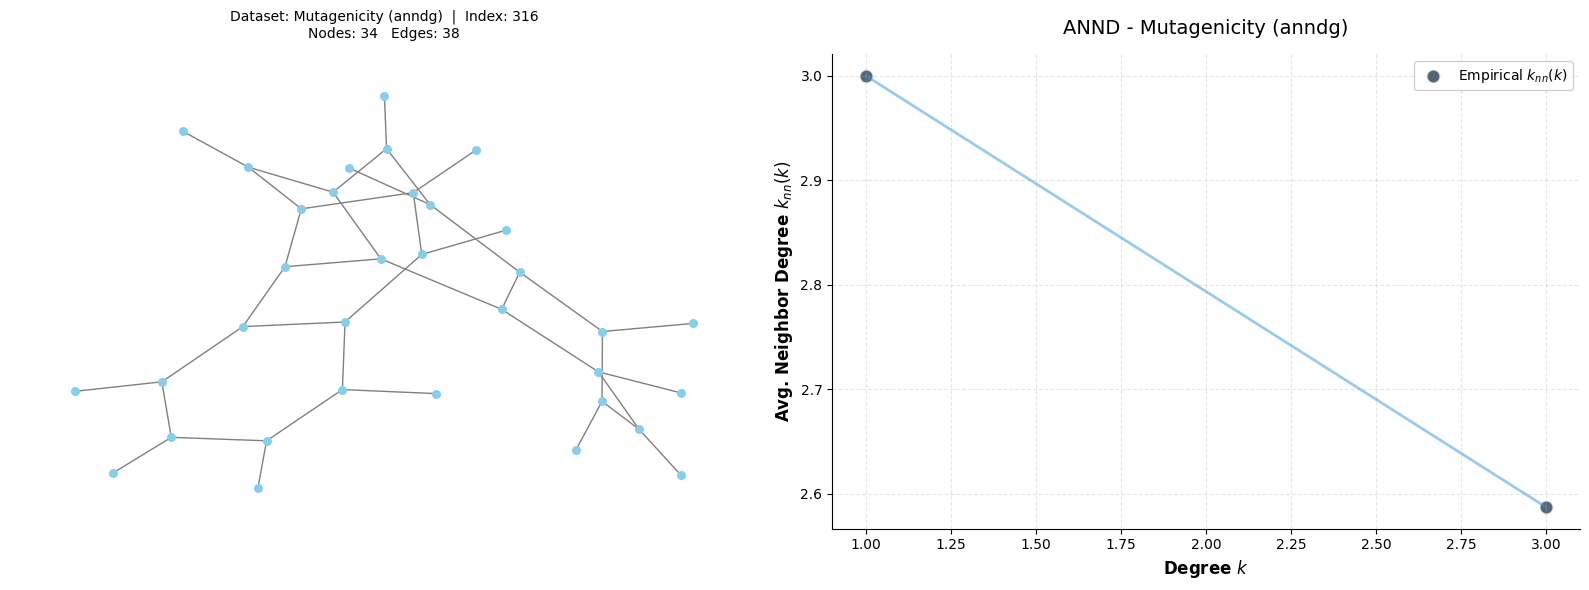

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

plot_graph(graph=GRAPH_NX, ax=ax1, dataset_name=f"{DATASET} ({METHOD})", graph_index=IDX)
plot_annd(graph=GRAPH_NX, ax=ax2, title=f"ANND - {DATASET} ({METHOD})")

# Calculate and print assortativity
target_stats = analyze_single_graph(GRAPH_IG)

plt.tight_layout()
plt.show()

Degree distribution:                     [0.32352941 0.05882353 0.55882353 0.02941176]
Initial ANND:                            [2.63636364 3.         2.68421053 3.        ]
Target ANND:                             [3.         0.         2.58730159]
Target ANND (adapted):                   [3.         2.79365079 2.58730159 2.45793651]
Indices present:                         [0 1 2 3]
Indices over ANND:                       [1 2 3]
Indices under ANND:                      [0]
Initial ANND error:                      0.243261
Step 100/10000 - Best error: 0.079537
Step 200/10000 - Best error: 0.079537
Step 300/10000 - Best error: 0.079537
Step 400/10000 - Best error: 0.079537
Step 500/10000 - Best error: 0.079537
Step 800/10000 - Best error: 0.079537
Step 900/10000 - Best error: 0.079537
Early stopping at step 911 - Best error: 0.079537
Final ANND error:                        0.079537


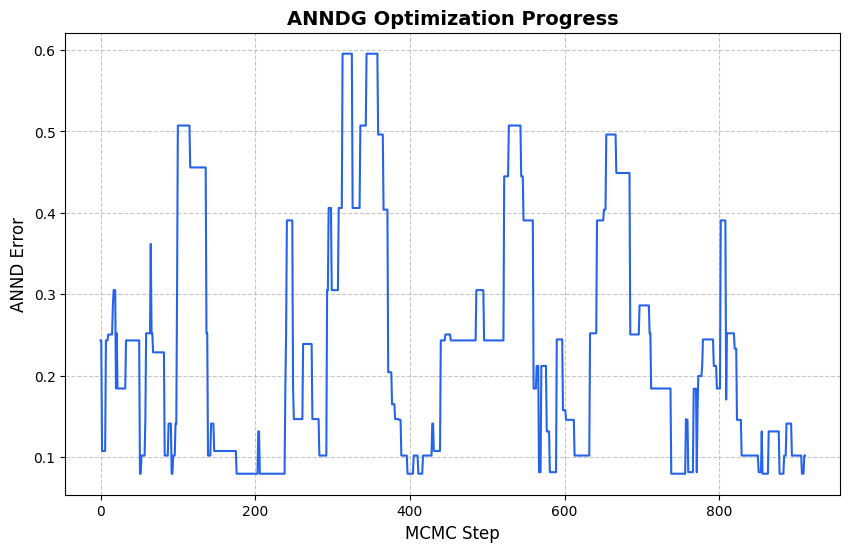

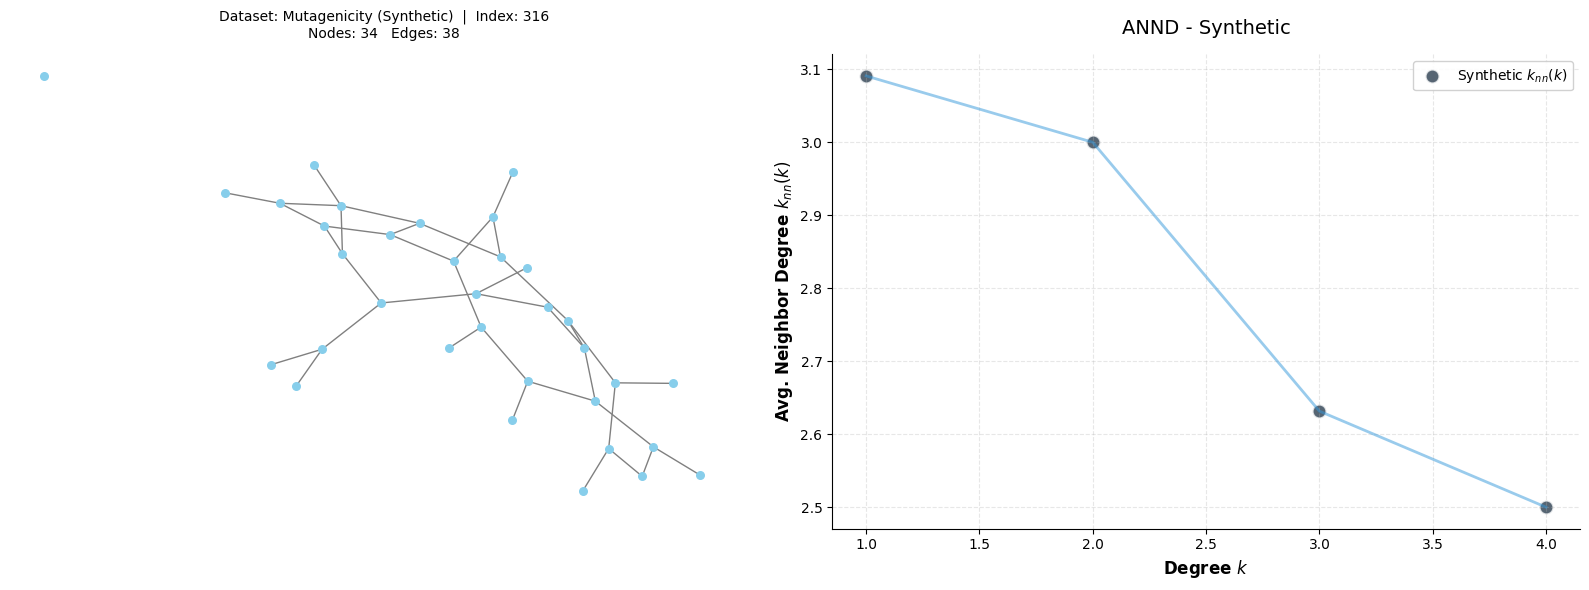


STRUCTURAL ERROR ANALYSIS
ANND Structural Error (Synthetic vs Anndg): 0.6006
Original Assortativity:  -0.2063
Synthetic Assortativity: -0.2272
Original ANND: [3.         0.         2.58730159]
Synthetic ANND: [3.09090909 3.         2.63157895 2.5       ]
Original Degree Moments: [ 6.77361854e-02  8.67434966e-04 -5.06821598e-01  1.14392060e+00]
Synthetic Degree Moments: [ 6.77361854e-02  9.75467160e-04 -5.04398614e-01  1.73322437e+00]


In [ ]:
# Generate synthetic graph
rng = np.random.default_rng(seed=230252435)
GRAPH_SYNTH_NX = generate_graph(target_stats, method=METHOD, rng=None)
GRAPH_SYNTH_IG = networkx_to_igraph(GRAPH_SYNTH_NX)

# Plot synthetic results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

plot_graph(graph=GRAPH_SYNTH_NX, ax=ax1, dataset_name=f"{DATASET} (Synthetic)", graph_index=IDX)
plot_annd(graph=GRAPH_SYNTH_NX, ax=ax2, title=f"ANND - Synthetic", label='Synthetic $k_{nn}(k)$')

# Calculate and print assortativity
obtained_stats = analyze_single_graph(GRAPH_SYNTH_IG)

plt.tight_layout()
plt.show()

print("\n" + "="*30)
print("STRUCTURAL ERROR ANALYSIS")
print("="*30)

# Calculate ANND and degree sequences for both graphs
deg_seq_original = np.array(GRAPH_IG.degree())
deg_seq_synthetic = np.array(GRAPH_SYNTH_IG.degree())

# Compute the structural error between the ANND of the synthetic and original graphs
annd_error = calculate_annd_error(
    obtained_annd=obtained_stats['annd'], 
    obtained_degree_sequence=deg_seq_synthetic, 
    target_annd=target_stats['annd'], 
    target_degree_sequence=deg_seq_original
)

print(f"ANND Structural Error (Synthetic vs {METHOD.capitalize()}): {annd_error:.4f}")
print(f"Original Assortativity:  {target_stats['assortativity']:.4f}")
print(f"Synthetic Assortativity: {obtained_stats['assortativity']:.4f}")
print(f"Original ANND: {target_stats['annd']}")
print(f"Synthetic ANND: {obtained_stats['annd']}")
print(f"Original Degree Moments: {target_stats['normalized_degree_moments']}")
print(f"Synthetic Degree Moments: {obtained_stats['normalized_degree_moments']}")
print("="*30)

In [ ]:
moment_losses = []
var_target, skew_target, kurt_target = 0.005,          0.34776035,     1.36691087
var_actual, skew_actual, kurt_actual = 6.41025641e-03, 2.21413796e-16, 7.27272727e-01

# Variance loss
var_scale = min(abs(var_actual), abs(var_target)) + 1e-6
var_err = abs(var_actual - var_target) / var_scale
moment_losses.append(np.log1p(var_err) ** 2.5)

# Skewness loss
if var_actual > 1e-12:
    skew_scale = min(abs(skew_actual), abs(skew_target)) + 1e-6
    skew_pct_error = abs(skew_actual - skew_target) / skew_scale
    skew_loss = np.log1p(skew_pct_error) ** 2.5
    moment_losses.append(skew_loss)

    # if skew_actual < 1e-6 and skew_target < 1e-6:
    #     moment_losses.append(0)

    # else:
    #     skew_actual_abs = abs(skew_actual)
    #     skew_target_abs = abs(skew_target)
    #     skew_scale = min(skew_actual_abs, skew_target_abs) if min(skew_actual_abs, skew_target_abs) > 1e-6 else max(skew_actual_abs, skew_target_abs) / 2

    #     skew_err = abs(skew_actual - skew_target) / skew_scale
    #     moment_losses.append(np.log1p(skew_err) ** 2.5)

# Kurtosis loss
kurt_scale = min(abs(kurt_actual), abs(kurt_target)) + 1e-6
kurt_err = abs(kurt_actual - kurt_target) / kurt_scale
moment_losses.append(np.log1p(kurt_err) ** 2.5)

print(moment_losses)

losses = np.asarray(moment_losses, dtype=float)
# L2 norm aggregation
penalty = float(np.mean(losses ** 2.0) ** 0.5)
print(penalty)

[np.float64(0.030757772917338947), np.float64(581.5200830574265), np.float64(0.3162892878796375)]
335.7408266227937
